## 402 Project 1

In [10]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip in

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

random_seed = 42
df = pd.read_csv("retail_trader_master.csv")


In [21]:
display(df.head())
display(df.isnull().sum())
display(df.duplicated().sum())

,trader_id,age,prior_experience_years,starting_capital,account_age_months,instrument,market_regime,broker_cost_bps,risk_per_trade_pct,avg_leverage,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
0,TRD000000,41,1.3,6670.0,6,forex,bull,16.9,1.40,6.2,...,0.6,0,6.6,2.9,5.2,7.3,9.2,-33.9,0,0
1,TRD000001,18,1.3,6230.0,10,futures,bull,4.7,0.76,13.6,...,4.1,2,3.6,10.0,5.5,7.7,10.0,-10.0,0,0
2,TRD000002,27,1.0,2530.0,9,forex,choppy,7.8,1.67,4.5,...,3.2,0,2.6,4.0,2.2,4.8,5.7,-21.6,0,0
3,TRD000003,55,1.9,6100.0,12,stocks,bull,12.1,2.52,2.3,...,5.6,0,2.6,6.8,7.4,10.0,6.8,4.8,1,0
4,TRD000004,34,1.5,7370.0,15,crypto,choppy,13.4,4.22,12.1,...,6.5,2,6.1,5.0,7.7,4.7,7.5,14.6,1,0


trader_id                     0
age                           0
prior_experience_years        0
starting_capital              0
account_age_months            0
instrument                    0
market_regime                 0
broker_cost_bps               0
risk_per_trade_pct            0
avg_leverage                  0
trades_per_month              0
uses_stop_loss                0
avg_win_hold_days             0
avg_loss_hold_days            0
diversification               0
journals_trades               0
revenge_trading               0
overconfidence                0
follows_plan                  0
chases_volatility             0
position_sizing_discipline    0
net_return_pct                0
profitable                    0
blew_up                       0
dtype: int64

np.int64(0)

In [22]:
display(df.describe())
display(df.info())

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.275840,2.231926,8918.229600,16.081660,12.012688,2.205167,6.138308,32.454440,0.519520,6.442136,...,4.033222,0.595880,5.006670,5.009076,5.344228,6.901380,7.380318,-21.352936,0.182380,0.450740
std,9.509957,1.880017,12180.900355,12.714182,8.449540,1.557809,5.753343,24.045368,0.499624,5.102338,...,2.120679,0.730135,2.238368,2.161649,2.267644,2.152017,2.117786,19.879813,0.386161,0.497573
min,18.000000,0.000000,200.000000,1.000000,0.500000,0.100000,1.000000,1.000000,0.000000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-62.000000,0.000000,0.000000
25%,27.000000,0.900000,2757.500000,7.000000,5.800000,1.060000,1.700000,15.000000,0.000000,2.700000,...,2.500000,0.000000,3.500000,3.500000,3.800000,5.400000,5.900000,-40.000000,0.000000,0.000000
50%,34.000000,1.700000,5390.000000,13.000000,10.100000,1.850000,4.200000,27.000000,1.000000,5.200000,...,4.000000,0.000000,5.000000,5.000000,5.400000,7.000000,7.600000,-24.900000,0.000000,0.000000
75%,41.000000,3.100000,10590.000000,22.000000,16.200000,2.960000,8.800000,44.000000,1.000000,8.800000,...,5.500000,1.000000,6.600000,6.500000,6.900000,8.600000,9.300000,-4.300000,0.000000,1.000000
max,75.000000,21.300000,401450.000000,120.000000,60.000000,15.570000,55.400000,251.000000,1.000000,60.000000,...,10.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,45.400000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trader_id                   50000 non-null  object 
 1   age                         50000 non-null  int64  
 2   prior_experience_years      50000 non-null  float64
 3   starting_capital            50000 non-null  float64
 4   account_age_months          50000 non-null  int64  
 5   instrument                  50000 non-null  object 
 6   market_regime               50000 non-null  object 
 7   broker_cost_bps             50000 non-null  float64
 8   risk_per_trade_pct          50000 non-null  float64
 9   avg_leverage                50000 non-null  float64
 10  trades_per_month            50000 non-null  int64  
 11  uses_stop_loss              50000 non-null  int64  
 12  avg_win_hold_days           50000 non-null  float64
 13  avg_loss_hold_days          500

None

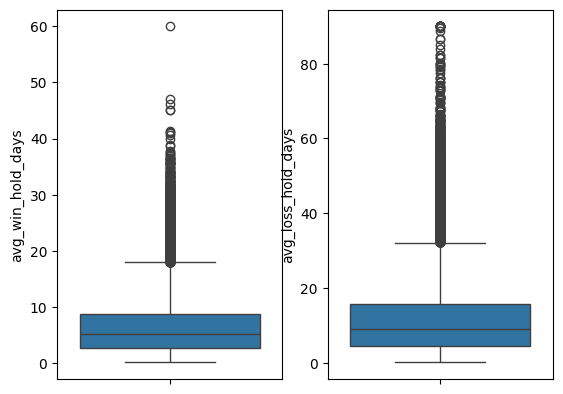

In [25]:


plt.subplot(1, 2, 1)
win=sns.boxplot(data=df, y='avg_win_hold_days')
plt.subplot(1, 2, 2)
loss=sns.boxplot(data=df, y='avg_loss_hold_days')

<Axes: xlabel='trades_per_month', ylabel='Count'>

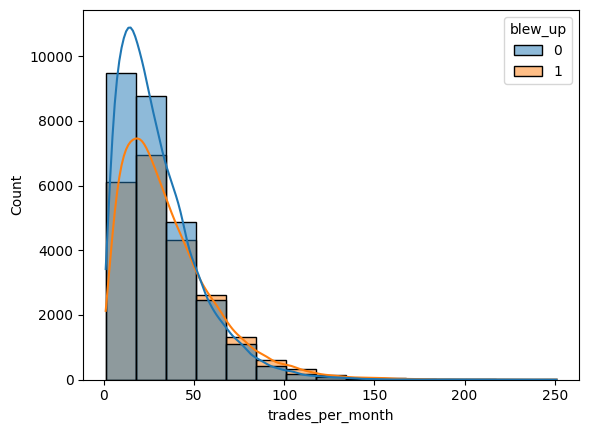

In [30]:
sns.histplot(data=df, hue='blew_up', x='trades_per_month', bins=15, kde=True)

<Axes: xlabel='revenge_trading', ylabel='net_return_pct'>

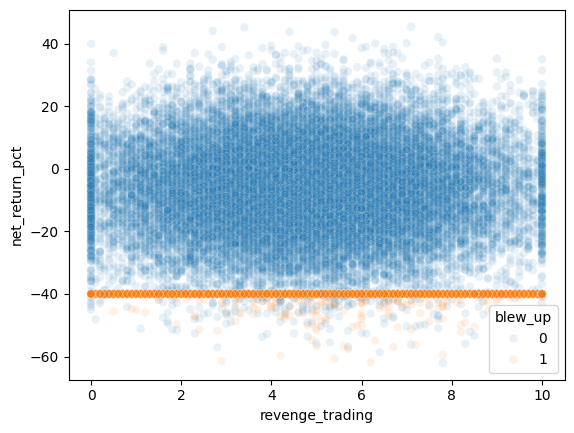

In [39]:
sns.scatterplot(data=df, x='revenge_trading', y='net_return_pct', alpha=0.1, hue='blew_up')

<Axes: xlabel='revenge_trading', ylabel='Density'>

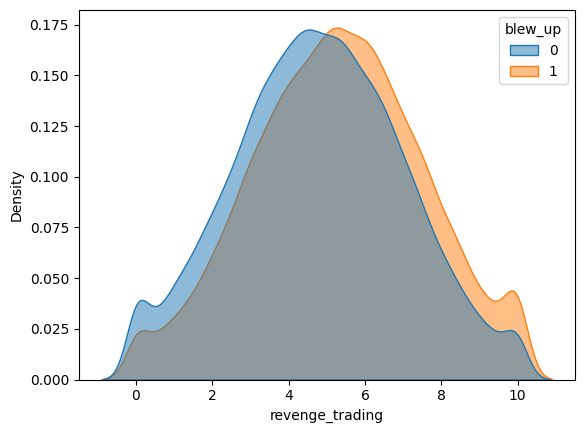

In [40]:
sns.kdeplot(data=df, x='revenge_trading', hue='blew_up', fill=True, common_norm=False, alpha=0.5)